In [4]:
from scipy.signal import stft
import scipy.stats
import numpy as np
import matplotlib.pyplot as plt

rzeczy do dodania:
- stft
- sk (spectral kurtosis)
- Jarque-Bera statistic
- KSS (Kolmogorov-Smirnov statistic)
- Anderson-Darling statistic
- QQplot (visual)
- local maxima selector

# dane testowe


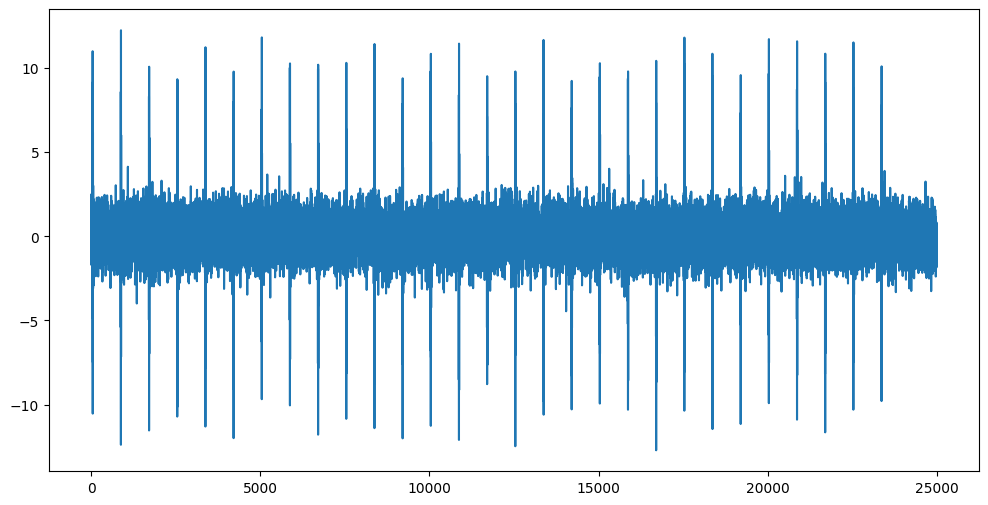

In [5]:
signal = np.loadtxt("assets/signal.csv")
plt.figure(figsize = (12 , 6))
plt.plot(signal)


# Short term Fourier Transform

In [ ]:
array_freq, array_tt, matrix_Zxx =stft(signal, fs = 25000, window = 'hann')
Zxx = np.abs(matrix_Zxx)

# Spectral Kurtosis (SK)

In [9]:
def SK(Zxx,f,t):
    abs_Zxx = np.abs(Zxx)
    num = np.sum(np.power(abs_Zxx[f,:],4))
    denum = np.sum(np.power(abs_Zxx[f,:],2))
    T = len(t)
    return (T*num/denum)-2 

Calculating SK for frequenzy 0.0:
Calculating SK for frequenzy 97.65624999999999:
Calculating SK for frequenzy 195.31249999999997:
Calculating SK for frequenzy 292.96874999999994:
Calculating SK for frequenzy 390.62499999999994:
Calculating SK for frequenzy 488.28124999999994:
Calculating SK for frequenzy 585.9374999999999:
Calculating SK for frequenzy 683.5937499999999:
Calculating SK for frequenzy 781.2499999999999:
Calculating SK for frequenzy 878.9062499999999:
Calculating SK for frequenzy 976.5624999999999:
Calculating SK for frequenzy 1074.2187499999998:
Calculating SK for frequenzy 1171.8749999999998:
Calculating SK for frequenzy 1269.5312499999998:
Calculating SK for frequenzy 1367.1874999999998:
Calculating SK for frequenzy 1464.8437499999998:
Calculating SK for frequenzy 1562.4999999999998:
Calculating SK for frequenzy 1660.1562499999998:
Calculating SK for frequenzy 1757.8124999999998:
Calculating SK for frequenzy 1855.4687499999998:
Calculating SK for frequenzy 1953.1249999

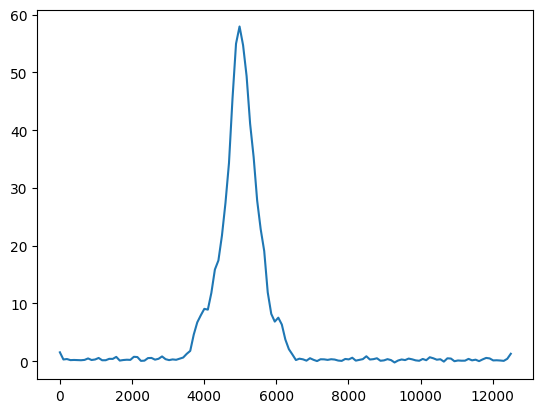

In [11]:
result = np.zeros_like(array_freq)

for i in range(0,len(array_freq)):
    print(f"Calculating SK for frequenzy {array_freq[i]}:")
    result[i] = SK(matrix_Zxx,i,array_tt)

plt.plot(array_freq,result)

STFT analizuje, jak moc sygnału w danym paśmie zmienia się w czasie.

Jeśli ta moc zmienia się losowo, ale z rozkładem normalnym → SK ≈ 0.

Jeśli pojawiają się momenty, gdzie moc „wystrzela” (impulsowe zdarzenia) → SK > 0.

Jeśli sygnał jest bardzo „gładki” → SK < 0.

# Jarque–Bera test (JB)


In [12]:
def JB(Zxx, f, t):
    abs_Zxx = np.abs(Zxx)
    s = scipy.stats.skew(abs_Zxx[f])
    k = scipy.stats.kurtosis(abs_Zxx[f])
    T = len(t)
    print(f"Skewness: {s}, kurtosis: {k}")
    return T/6 * (s**2 + (np.power(k-1,2)/4))

for i in range(0,len(array_freq)):
    print(f"Calculating JB for frequenzy {array_freq[i]}:")
    print(f"JB statistic: {JB(matrix_Zxx,i,array_tt)}")

Calculating JB for frequenzy 0.0:
Skewness: 0.8465354552128118, kurtosis: 0.2887674849262152
JB statistic: 27.68129738545181
Calculating JB for frequenzy 97.65624999999999:
Skewness: 0.4853446304905547, kurtosis: -0.3363912658785546
JB statistic: 22.39380473372525
Calculating JB for frequenzy 195.31249999999997:
Skewness: 0.7536607057247767, kurtosis: 1.614150813839581
JB statistic: 21.745508947173185
Calculating JB for frequenzy 292.96874999999994:
Skewness: 0.6193041983208806, kurtosis: 0.5289211254641244
JB statistic: 14.414375627262332
Calculating JB for frequenzy 390.62499999999994:
Skewness: 0.5580078145361512, kurtosis: 0.09887215417129669
JB statistic: 16.88882870565503
Calculating JB for frequenzy 488.28124999999994:
Skewness: 0.4045380703616501, kurtosis: -0.42308659105113344
JB statistic: 21.996524603420724
Calculating JB for frequenzy 585.9374999999999:
Skewness: 0.3219930691696728, kurtosis: -0.6582589556069434
JB statistic: 25.975606638087463
Calculating JB for frequenzy 

# Kolmogorov-Smirnov Statistic (KSS)

In [13]:
def KSS(Zxx,f,t):
    abs_Zxx = np.abs(Zxx)
    mean_signal = np.mean(abs_Zxx[f])
    std_signal = np.std(abs_Zxx[f])
    cdf_sample = np.zeros_like(t)
    for i in range(len(t)):
        cdf_sample[i] = scipy.stats.norm.cdf(t[i],loc=mean_signal, scale=std_signal)
    return(scipy.stats.kstest(abs_Zxx[f],cdf_sample))



In [14]:
for i in range(0,len(array_freq)):
    print(f"Calculating KSS for frequenzy {array_freq[i]}:")
    p_value = KSS(matrix_Zxx,i,array_tt).pvalue
    print(f"KSS statistic: {p_value}")

Calculating KSS for frequenzy 0.0:
KSS statistic: 6.170617539637008e-105
Calculating KSS for frequenzy 97.65624999999999:
KSS statistic: 1.654562941574526e-101
Calculating KSS for frequenzy 195.31249999999997:
KSS statistic: 1.654562941574526e-101
Calculating KSS for frequenzy 292.96874999999994:
KSS statistic: 3.4202851505416556e-103
Calculating KSS for frequenzy 390.62499999999994:
KSS statistic: 1.654562941574526e-101
Calculating KSS for frequenzy 488.28124999999994:
KSS statistic: 3.4202851505416556e-103
Calculating KSS for frequenzy 585.9374999999999:
KSS statistic: 3.4202851505416556e-103
Calculating KSS for frequenzy 683.5937499999999:
KSS statistic: 3.4202851505416556e-103
Calculating KSS for frequenzy 781.2499999999999:
KSS statistic: 1.654562941574526e-101
Calculating KSS for frequenzy 878.9062499999999:
KSS statistic: 3.4202851505416556e-103
Calculating KSS for frequenzy 976.5624999999999:
KSS statistic: 3.4202851505416556e-103
Calculating KSS for frequenzy 1074.218749999999

# Anderson Darling statistic(Q)

Tutaj będzie trzeba się trochę bardziej zagłębić w to, co jest zwracane w tej funkcji, bo nie ma bezpośrednio zwróconej p-wartości, tylko raczej wartości krytyczne(jeśli to nie jest to samo lol)

In [ ]:
for i in range(0,len(array_freq)):
    print(f"Calculating Q for frequenzy {array_freq[i]}:")
    result = scipy.stats.anderson(abs_Zxx[i], dist='norm')
    print(np.int64(result.statistic < result.critical_values[2]))


Calculating Q for frequenzy 0.0:
0
Calculating Q for frequenzy 3.90625:
1
Calculating Q for frequenzy 7.8125:
1
Calculating Q for frequenzy 11.71875:
1
Calculating Q for frequenzy 15.625:
0
Calculating Q for frequenzy 19.53125:
1
Calculating Q for frequenzy 23.4375:
1
Calculating Q for frequenzy 27.34375:
1
Calculating Q for frequenzy 31.25:
1
Calculating Q for frequenzy 35.15625:
0
Calculating Q for frequenzy 39.0625:
0
Calculating Q for frequenzy 42.96875:
0
Calculating Q for frequenzy 46.875:
1
Calculating Q for frequenzy 50.78125:
1
Calculating Q for frequenzy 54.6875:
1
Calculating Q for frequenzy 58.59375:
1
Calculating Q for frequenzy 62.5:
1
Calculating Q for frequenzy 66.40625:
1
Calculating Q for frequenzy 70.3125:
0
Calculating Q for frequenzy 74.21875:
1
Calculating Q for frequenzy 78.125:
1
Calculating Q for frequenzy 82.03125:
0
Calculating Q for frequenzy 85.9375:
1
Calculating Q for frequenzy 89.84375:
1
Calculating Q for frequenzy 93.75:
1
Calculating Q for frequenzy 9

# QQplot

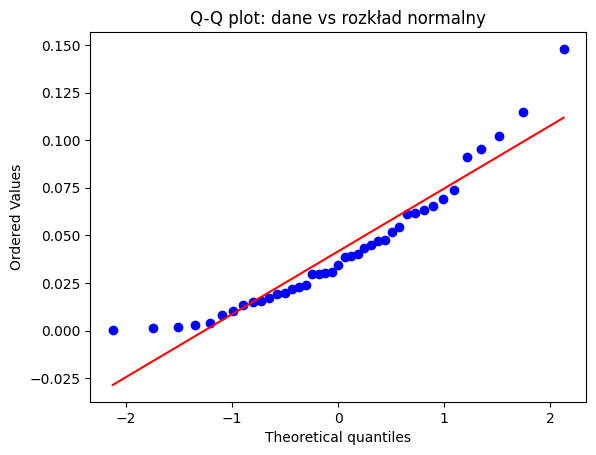

In [ ]:
temp = abs_Zxx[0]
scipy.stats.probplot(temp, dist="norm", plot=plt)
plt.title("Q-Q plot: dane vs rozkład normalny")
plt.show()

# CVS (Conditional Variance Statistic)

Kroki w postępowaniu:
- Przujmyjemy że dany zbiór Y jest N(mi, sigma)
- dla pewnego 0 < q < 0.5 obliczamy kwantyl q, 1-q i to pomiędzy nimi, czyli z pdf L, R i M
- na podstawie tych zbiorów obliczamy sigmy elementów leżących w tych zbiorach
- mając te sigmy wstawiamy je do wzoru na statystykę testu

In [ ]:
def cvs(signal,fs=25000,q=0.2):
    array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
    Zxx=abs(matrix_Zxx)
    F = Zxx.shape[0]
    T = Zxx.shape[1]

    results = np.zeros(F)
    for f in range(F):

        sorted_signal = np.sort(Zxx[f])
        lower_threshold = np.quantile(sorted_signal, q)
        upper_threshold = np.quantile(sorted_signal, 1-q)
        L = sorted_signal[sorted_signal <= lower_threshold]
        R = sorted_signal[sorted_signal > upper_threshold]
        M = sorted_signal[(lower_threshold < sorted_signal) & ( sorted_signal<= upper_threshold)]

        #obliczanie statystyki testowej N
        p=1

        N = 1/p * ((np.var(L)-np.var(M))/np.var(Zxx[0])+(np.var(R)-np.var(M))/np.var(Zxx[0])) * np.sqrt(len(Zxx[f]))

        results[f] = N

    return results


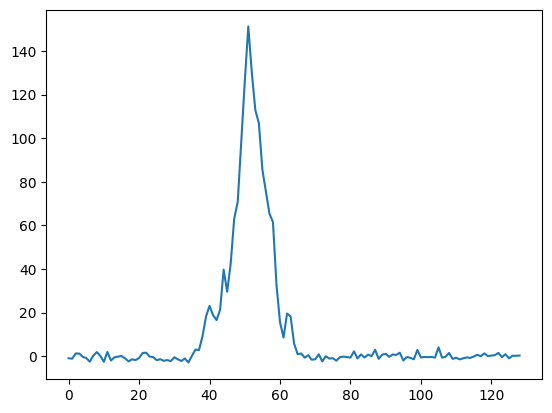

In [51]:
csv_results = cvs(signal)
plt.plot(csv_results)